In [22]:
#all imports necessary for the project
import numpy as np
import cv2
import os
import tensorflow as tf
import random

from tensorflow.keras import layers, models, Model
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import image_dataset_from_directory

import matplotlib.pyplot as plt

In [23]:
model = load_model("C:/temp/dogs/best_model.h5")

In [24]:
#configuring image size and batch size for tthe model, compatible with MobileNetV2
IMAGE_SIZE = (224, 224)
IMAGE_FULL_SIZE = (224, 224, 3)
BATCH_SIZE = 8 # the batch size is small due to technical limitations

In [25]:
#dataset paths to the downloaded image folders containing the training and testing images
trainImgfolder = "C:/Users/marto/OneDrive - Budapesti Műszaki és Gazdaságtudományi Egyetem/ML/priject/pp/dogImages/train"
testImgfolder = "C:/Users/marto/OneDrive - Budapesti Műszaki és Gazdaságtudományi Egyetem/ML/priject/pp/dogImages/test"
validImgfolder = "C:/Users/marto/OneDrive - Budapesti Műszaki és Gazdaságtudományi Egyetem/ML/priject/pp/dogImages/valid"

#tensorflow datast loader
def load_image_dataset(
    trainImgfolder,
    img_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    categorical=True,
    shuffle=True
):
    label_mode = "categorical" if categorical else "int" # formatting thelabels to one-hot (integer) labels
#loading the dataset from the folders and formattign the images to the desired size, and batch size, also shuffling the imaes for better ttraining
    ds = tf.keras.utils.image_dataset_from_directory(
        trainImgfolder,
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        label_mode=label_mode,
        shuffle=shuffle
    )


#extracting thhe class names(dog breeds)
    class_names = ds.class_names
    return ds, class_names


In [26]:
#loads the test dataset as tensorflow dataset with the same format as the training dataset
test_ds, class_names = load_image_dataset(
    testImgfolder,
    categorical=True,
    shuffle=True
)

Found 836 files belonging to 133 classes.


In [27]:
#manual dataset loader used for training
def load_dataset(root_dir, img_size=(224, 224)):
    X = [] #images
    y = []  #labels
    class_names = []
#iterating over each class folder
    for class_name in sorted(os.listdir(root_dir)):
        class_path = os.path.join(root_dir, class_name)

        if not os.path.isdir(class_path):
            continue

        class_names.append(class_name)
        label = len(class_names) - 1 #assigning numerical label

#loading all images from the lass folder
        for fname in os.listdir(class_path):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            path = os.path.join(class_path, fname)
#reading image using OpenCV
            img = cv2.imdecode(np.fromfile(path, dtype=np.uint8), cv2.IMREAD_COLOR)

            if img is None:
                continue
#converting BGR-> RGB as openCV uses BGR by default, resize to model input size
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, img_size)

            X.append(img)
            y.append(label)
#normalizepixel values to [0,1] for stable NN training, convert to float32 to save memory, and convert labels to int32
    X = np.array(X, dtype=np.float32) / 255.0
    y = np.array(y, dtype=np.int32)

    return X, y, class_names 

In [28]:
#loading datasets into memory
X_train, y_train, class_names = load_dataset(trainImgfolder)
X_test, y_test, _ = load_dataset(testImgfolder)
X_val, y_val, _ = load_dataset(validImgfolder)
X_custom, y_custom, _ = load_dataset(r"C:\Users\marto\OneDrive - Budapesti Műszaki és Gazdaságtudományi Egyetem\ML\priject\images\pp\dogImages\custom")

#checking dataset shapes to make sure they are loaded correctly
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)
print(X_custom.shape)

(6679, 224, 224, 3)
(836, 224, 224, 3)
(835, 224, 224, 3)
(2, 224, 224, 3)


In [29]:
#number of classes (dog breeds)
numOfCategories = len(np.unique(y_train))
print(numOfCategories)

133


In [30]:
predictions = model.predict(X_test, verbose=0)

pred_labels = np.argmax(predictions, axis=1)

# Handle both one-hot and integer labels safely
if len(y_test.shape) > 1:
    true_labels = np.argmax(y_test, axis=1)
else:
    true_labels = y_test

confidences = np.max(predictions, axis=1)

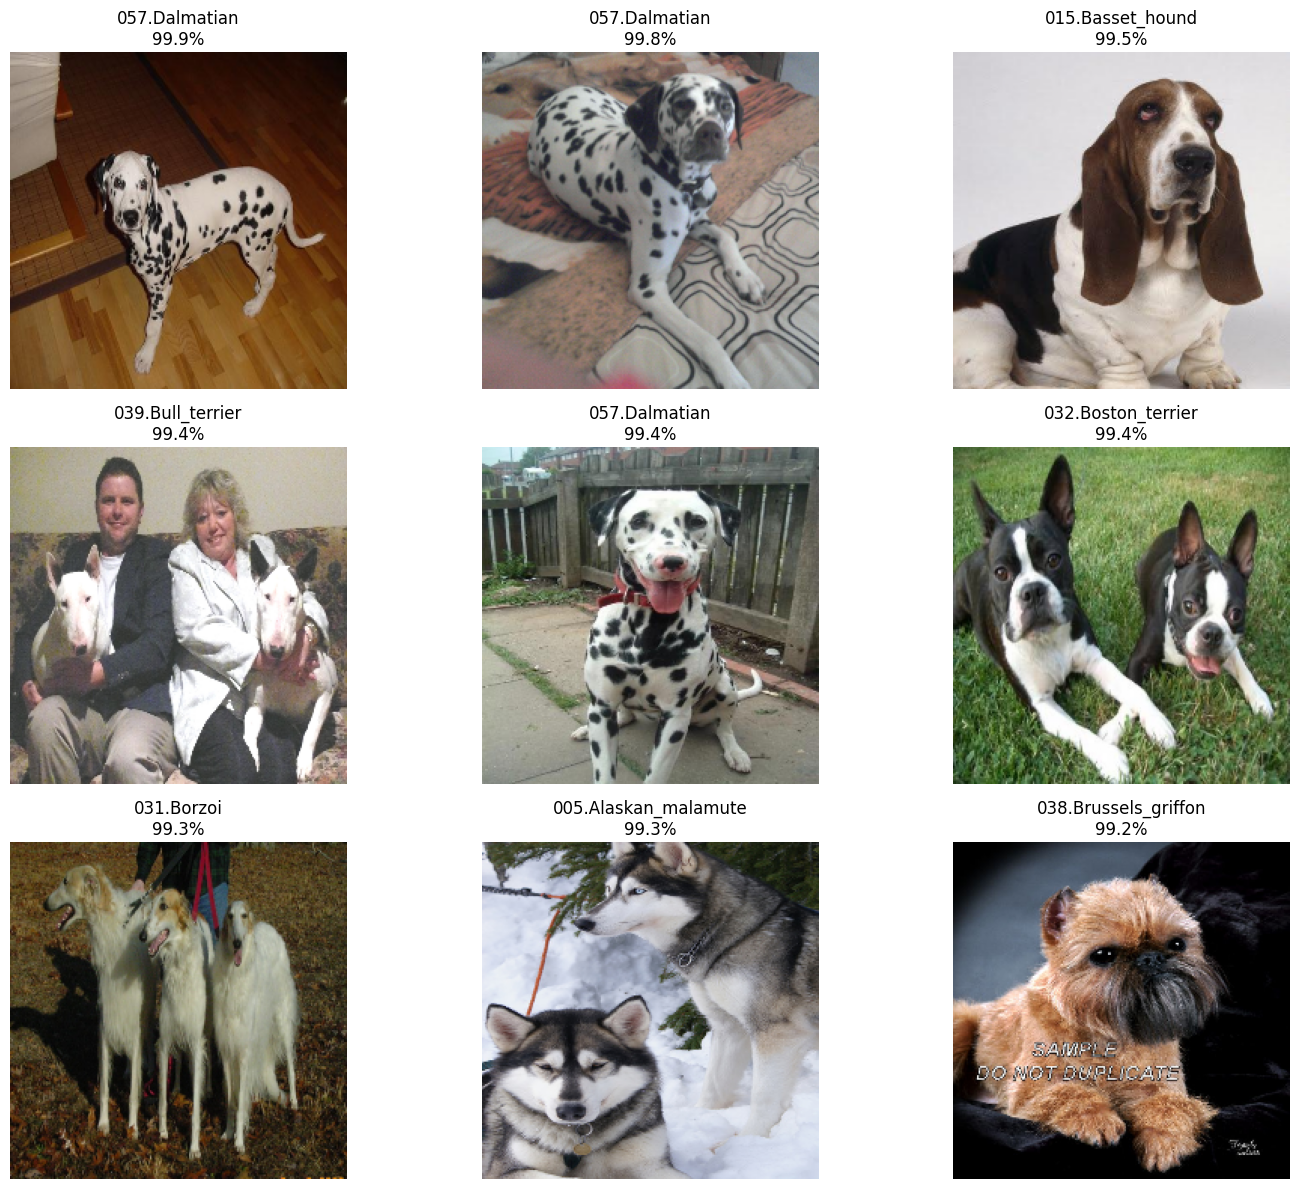

In [44]:
correct = np.where(pred_labels == true_labels)[0]

# sort correct ones by confidence descending
best = correct[np.argsort(confidences[correct])[::-1]]

plt.figure(figsize=(15,12))

for i, idx in enumerate(best[:9]):
    plt.subplot(3,3,i+1)
    
    plt.imshow(X_test[idx])
    
    plt.title(
        f"{class_names[pred_labels[idx]]}\n"
        f"{confidences[idx]*100:.1f}%"
    )
    
    plt.axis("off")

plt.tight_layout()

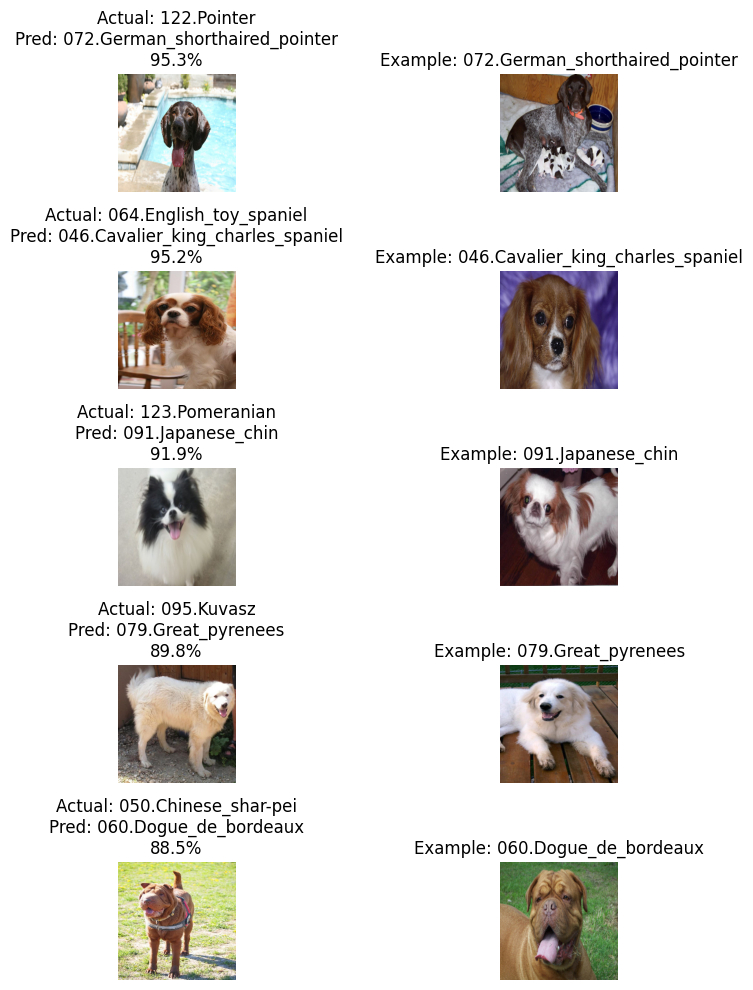

In [32]:
wrong = np.where(pred_labels != true_labels)[0]

# sort by confidence (show confident mistakes)
wrong = wrong[np.argsort(confidences[wrong])[::-1]]

plt.figure(figsize=(10,10))

for i, idx in enumerate(wrong[:5]):

    pred_class = pred_labels[idx]

    candidates = np.where(
        (true_labels == pred_class) &
        (pred_labels == pred_class)
    )[0]

    if len(candidates) > 0:
        ref_idx = candidates[0]
    else:
        ref_idx = idx

    plt.subplot(5, 2, 2*i + 1)
    plt.imshow(X_test[idx])
    plt.title(
        f"Actual: {class_names[true_labels[idx]]}\n"
        f"Pred: {class_names[pred_labels[idx]]}\n"
        f"{confidences[idx]*100:.1f}%"
    )
    plt.axis("off")

    plt.subplot(5, 2, 2*i + 2)
    plt.imshow(X_test[ref_idx])
    plt.title(f"Example: {class_names[pred_class]}")
    plt.axis("off")

plt.tight_layout()

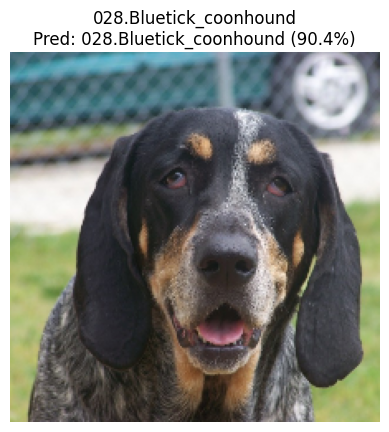

Top-5 Predictions:

1. 028.Bluetick_coonhound 90.36%
2. 077.Gordon_setter 4.50%
3. 025.Black_and_tan_coonhound 2.32%
4. 015.Basset_hound 0.81%
5. 062.English_setter 0.57%


In [33]:
idx = random.randint(0, len(X_test)-1)

probs = predictions[idx]
top5 = np.argsort(probs)[::-1][:5]

plt.imshow(X_test[idx])
plt.axis("off")

plt.title(
    f"{class_names[true_labels[idx]]}\n"
    f"Pred: {class_names[pred_labels[idx]]} ({confidences[idx]*100:.1f}%)"
)

plt.show()

print("Top-5 Predictions:\n")

for rank, c in enumerate(top5, start=1):
    print(f"{rank}. {class_names[c]} {probs[c]*100:.2f}%")

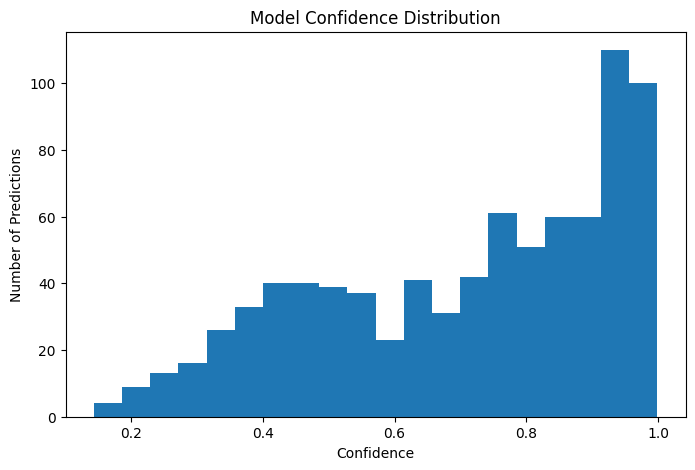

In [34]:
plt.figure(figsize=(8,5))

plt.hist(confidences, bins=20)

plt.xlabel("Confidence")
plt.ylabel("Number of Predictions")
plt.title("Model Confidence Distribution")

plt.show()

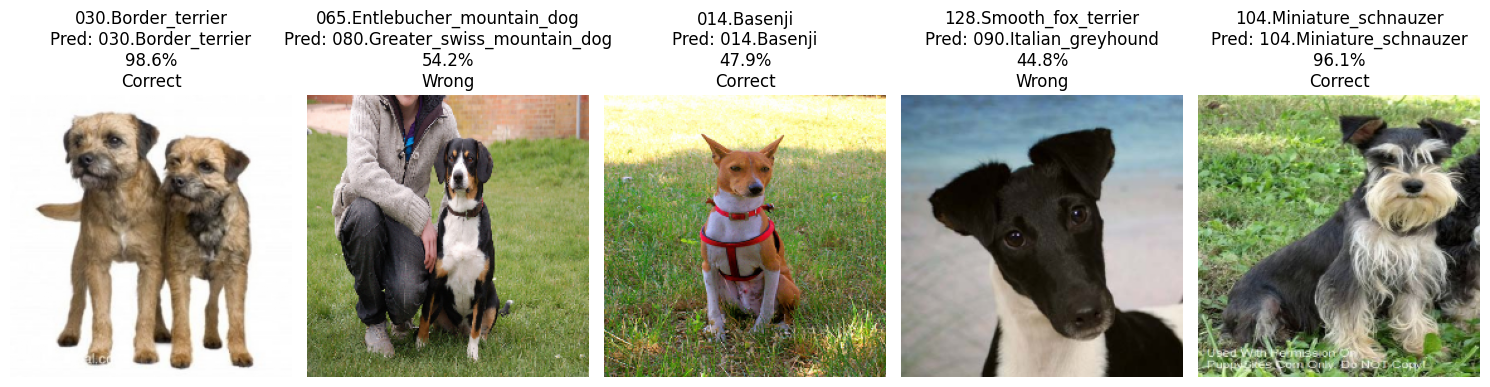

In [35]:
plt.figure(figsize=(15,6))

for i in range(5):
    idx = random.randint(0, len(X_test)-1)

    correct = pred_labels[idx] == true_labels[idx]

    plt.subplot(1,5,i+1)
    plt.imshow(X_test[idx])

    plt.title(
        f"{class_names[true_labels[idx]]}\n"
        f"Pred: {class_names[pred_labels[idx]]}\n"
        f"{confidences[idx]*100:.1f}%\n"
        f"{'Correct' if correct else 'Wrong'}"
    )

    plt.axis("off")

plt.tight_layout()

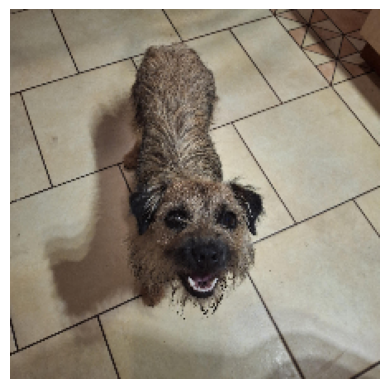

Image 1 — Top 5 Predictions:

1. 042.Cairn_terrier 38.57%
2. 089.Irish_wolfhound 27.64%
3. 075.Glen_of_imaal_terrier 19.95%
4. 087.Irish_terrier 3.04%
5. 030.Border_terrier 1.43%




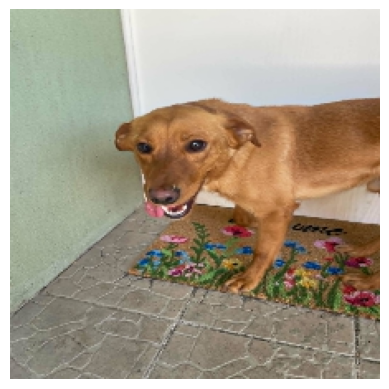

Image 2 — Top 5 Predictions:

1. 047.Chesapeake_bay_retriever 52.49%
2. 120.Pharaoh_hound 14.30%
3. 070.German_pinscher 10.99%
4. 112.Nova_scotia_duck_tolling_retriever 7.19%
5. 056.Dachshund 6.07%




In [36]:
preds = model.predict(X_custom, verbose=0)

for i in range(len(X_custom)):
    probs = preds[i]

    # get top 5 indices
    top5 = np.argsort(probs)[::-1][:5]

    # show image
    plt.imshow(X_custom[i])
    plt.axis("off")
    plt.show()

    # print results
    print(f"Image {i+1} — Top 5 Predictions:\n")

    for rank, c in enumerate(top5, start=1):
        print(f"{rank}. {class_names[c]} {probs[c]*100:.2f}%")

    print("\n")

In [43]:
#adding Gaussian noise to the image
#sigma is the variance, larger value means greater distorsion
def add_gaussian_noise(img, sigma):
    noise = np.random.normal(loc=0.0, scale=sigma, size=img.shape).astype(np.float32)
    noisy_img = img.astype(np.float32) + noise
    noisy_img = np.clip(noisy_img, 0.0, 1.0)  #the value is set between 0 and 1
    return noisy_img

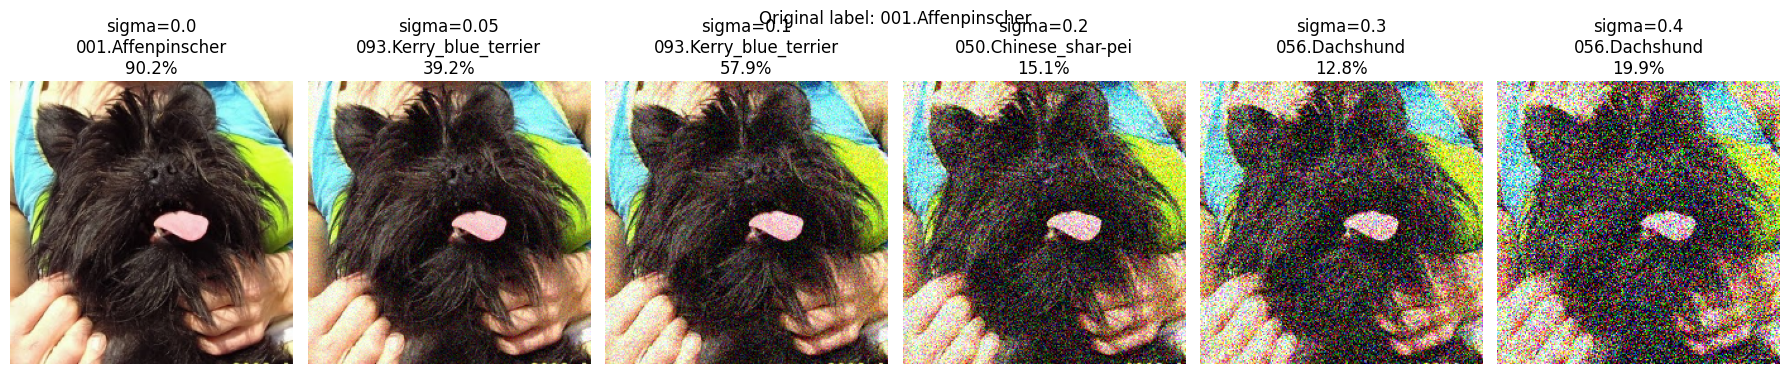

In [46]:
#get correctly classified images
correct = np.where(pred_labels == true_labels)[0]

# Choose one correctly classified image
demo_idx = correct[0]

demo_img = X_test[demo_idx]
true_class = class_names[true_labels[demo_idx]]

noise_levels = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4]

plt.figure(figsize=(18, 4))

for i, sigma in enumerate(noise_levels):
    noisy_img = add_gaussian_noise(demo_img, sigma)

    pred = model.predict(noisy_img[None, ...], verbose=0)
    pred_class = class_names[np.argmax(pred)]
    confidence = np.max(pred)

    plt.subplot(1, len(noise_levels), i + 1)
    plt.imshow(noisy_img)
    plt.axis("off")
    plt.title(f"sigma={sigma}\n{pred_class}\n{confidence*100:.1f}%")

plt.suptitle(f"Original label: {true_class}")
plt.tight_layout()
plt.show()

sigma=0.00 -> accuracy=81.0%
sigma=0.05 -> accuracy=75.0%
sigma=0.10 -> accuracy=56.0%
sigma=0.15 -> accuracy=24.5%
sigma=0.20 -> accuracy=9.0%
sigma=0.25 -> accuracy=2.0%
sigma=0.30 -> accuracy=2.0%
sigma=0.35 -> accuracy=3.0%
sigma=0.40 -> accuracy=2.0%


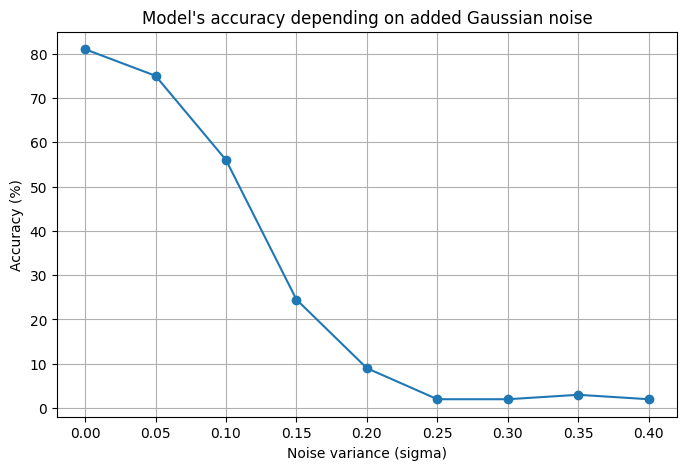

In [47]:
#Quantify how predictions get worse for a portion of images (200)
#Noise goes from 0 to 0.4 in 0.05 steps and accuracy is calculated for each step
sample_size = min(200, len(X_test))
sample_idx = np.random.choice(len(X_test), size=sample_size, replace=False)
X_sample = X_test[sample_idx]
y_sample = true_labels[sample_idx]

noise_levels_eval = np.arange(0.0, 0.45, 0.05)
accuracies = []

for sigma in noise_levels_eval:
    noise = np.random.normal(loc=0.0, scale=sigma, size=X_sample.shape).astype(np.float32)
    noisy_batch = np.clip(X_sample.astype(np.float32) + noise, 0.0, 1.0)

    preds = model.predict(noisy_batch, verbose=0)
    pred_labels_noisy = np.argmax(preds, axis=1)

    acc = np.mean(pred_labels_noisy == y_sample)
    accuracies.append(acc)
    print(f"sigma={sigma:.2f} -> accuracy={acc*100:.1f}%")

plt.figure(figsize=(8, 5))
plt.plot(noise_levels_eval, np.array(accuracies) * 100, marker='o')
plt.xlabel("Noise variance (sigma)")
plt.ylabel("Accuracy (%)")
plt.title("Model's accuracy depending on added Gaussian noise")
plt.grid(True)
plt.show()
